# Thesis Pipeline Showcase (Supervisor Presentation)

This notebook demonstrates the **current implemented thesis pipeline** end to end using indexed data and audited pilot artifacts.

- Primary target: `coarse_affect`
- Primary evidence path: `within_subject_loso_session`
- Secondary evidence path: `frozen_cross_person_transfer`
- Auxiliary grouped mode: `loso_session` (non-primary)
- Interpretability outputs are supporting model-behavior robustness evidence, not neural localization claims.


In [1]:
from __future__ import annotations

from collections import OrderedDict
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


def find_repo_root(start: Path) -> Path:
    for c in [start.resolve(), *start.resolve().parents]:
        if (c / "pyproject.toml").exists():
            return c
    raise FileNotFoundError("Could not locate repo root.")


def read_json(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def split_pipe(v) -> list[str]:
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return []
    text = str(v).strip()
    return [x for x in text.split("|") if x] if text else []


REPO_ROOT = find_repo_root(Path.cwd())
DATA_INDEX = REPO_ROOT / "Data" / "processed" / "dataset_index.csv"
REPORTS = REPO_ROOT / "reports" / "experiments"

def discover_latest_run_id(
    mode: str,
    subject: str | None = None,
    train_subject: str | None = None,
    test_subject: str | None = None,
    target: str = "coarse_affect",
    model: str = "ridge",
) -> str:
    if not REPORTS.exists():
        raise FileNotFoundError(f"Reports directory does not exist: {REPORTS}")

    candidates: list[tuple[float, str]] = []
    for run_path in REPORTS.iterdir():
        if not run_path.is_dir():
            continue
        cfg = read_json(run_path / "config.json")
        if not isinstance(cfg, dict):
            continue

        exp_mode = cfg.get("experiment_mode") or cfg.get("cv")
        if exp_mode != mode:
            continue
        if str(cfg.get("target")) != target:
            continue
        if str(cfg.get("model")) != model:
            continue

        if mode == "within_subject_loso_session":
            if str(cfg.get("subject")) != str(subject):
                continue
        elif mode == "frozen_cross_person_transfer":
            if str(cfg.get("train_subject")) != str(train_subject):
                continue
            if str(cfg.get("test_subject")) != str(test_subject):
                continue

        metrics_path = run_path / "metrics.json"
        if not metrics_path.exists():
            continue
        candidates.append((metrics_path.stat().st_mtime, run_path.name))

    if not candidates:
        criteria = {
            "mode": mode,
            "subject": subject,
            "train_subject": train_subject,
            "test_subject": test_subject,
            "target": target,
            "model": model,
        }
        raise FileNotFoundError(f"No matching run found for criteria: {criteria}")

    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]


RUN_SPECS = OrderedDict(
    {
        "within_sub001": {
            "mode": "within_subject_loso_session",
            "subject": "sub-001",
            "train_subject": None,
            "test_subject": None,
        },
        "within_sub002": {
            "mode": "within_subject_loso_session",
            "subject": "sub-002",
            "train_subject": None,
            "test_subject": None,
        },
        "transfer_001_to_002": {
            "mode": "frozen_cross_person_transfer",
            "subject": None,
            "train_subject": "sub-001",
            "test_subject": "sub-002",
        },
        "transfer_002_to_001": {
            "mode": "frozen_cross_person_transfer",
            "subject": None,
            "train_subject": "sub-002",
            "test_subject": "sub-001",
        },
    }
)

RUNS = OrderedDict()
for key, spec in RUN_SPECS.items():
    run_id = discover_latest_run_id(
        mode=spec["mode"],
        subject=spec.get("subject"),
        train_subject=spec.get("train_subject"),
        test_subject=spec.get("test_subject"),
    )
    RUNS[key] = {**spec, "run_id": run_id}

ARTIFACTS = [
    "config.json",
    "metrics.json",
    "fold_metrics.csv",
    "fold_splits.csv",
    "predictions.csv",
    "spatial_compatibility_report.json",
    "interpretability_summary.json",
    "interpretability_fold_explanations.csv",
]


def run_dir(run_key: str) -> Path:
    return REPORTS / RUNS[run_key]["run_id"] # type: ignore


def load_run(run_key: str) -> dict:
    d = run_dir(run_key)
    return {
        "run_dir": d,
        "config": read_json(d / "config.json"),
        "metrics": read_json(d / "metrics.json"),
        "fold_metrics": read_csv(d / "fold_metrics.csv"),
        "fold_splits": read_csv(d / "fold_splits.csv"),
        "predictions": read_csv(d / "predictions.csv"),
        "spatial": read_json(d / "spatial_compatibility_report.json"),
        "interp_summary": read_json(d / "interpretability_summary.json"),
        "interp_folds": read_csv(d / "interpretability_fold_explanations.csv"),
    }


RUN_DATA = {k: load_run(k) for k in RUNS}
print(f"Repo root: {REPO_ROOT}")
print(f"Index path: {DATA_INDEX} (exists={DATA_INDEX.exists()})")
for k in RUNS:
    print(f"{k}: {run_dir(k)} (exists={run_dir(k).exists()})")


Repo root: D:\Khaled\Projects\VScode\Thesis
Index path: D:\Khaled\Projects\VScode\Thesis\Data\processed\dataset_index.csv (exists=True)
within_sub001: D:\Khaled\Projects\VScode\Thesis\reports\experiments\healthcheck_20260311_within_sub001_ridge (exists=True)
within_sub002: D:\Khaled\Projects\VScode\Thesis\reports\experiments\healthcheck_20260311_within_sub002_ridge (exists=True)
transfer_001_to_002: D:\Khaled\Projects\VScode\Thesis\reports\experiments\healthcheck_20260311_transfer_sub001_to_sub002_ridge (exists=True)
transfer_002_to_001: D:\Khaled\Projects\VScode\Thesis\reports\experiments\healthcheck_20260311_transfer_sub002_to_sub001_ridge (exists=True)


## 1) Pipeline Overview

Implemented flow:
SPM beta maps -> dataset index -> feature cache -> spatial compatibility check -> experiment execution -> auditable artifacts -> interpretability summary for supported linear within-subject runs.


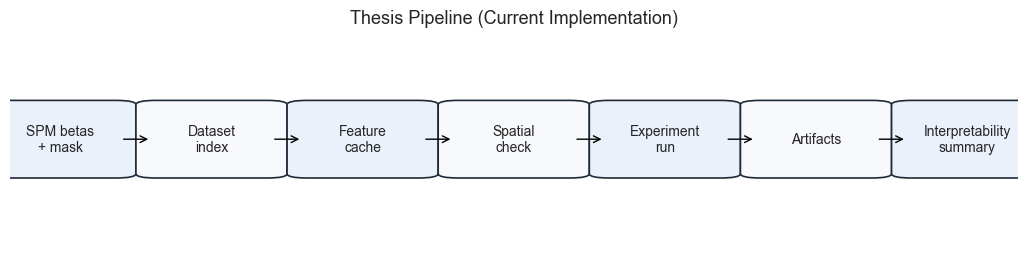

In [2]:
fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis("off")
steps = [
    "SPM betas\n+ mask",
    "Dataset\nindex",
    "Feature\ncache",
    "Spatial\ncheck",
    "Experiment\nrun",
    "Artifacts",
    "Interpretability\nsummary",
]
xs = np.linspace(0.05, 0.95, len(steps))
for i, (x, t) in enumerate(zip(xs, steps)):
    ax.add_patch(
        FancyBboxPatch(
            (x - 0.055, 0.34),
            0.11,
            0.32,
            boxstyle="round,pad=0.02",
            linewidth=1.2,
            edgecolor="#1f2937",
            facecolor="#eaf1fb" if i % 2 == 0 else "#f7f9fc",
        )
    )
    ax.text(x, 0.5, t, ha="center", va="center", fontsize=10)
for l, r in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((l + 0.06, 0.5), (r - 0.06, 0.5), arrowstyle="->", mutation_scale=12))
ax.set_title("Thesis Pipeline (Current Implementation)", fontsize=13)
plt.show()


## 2) Project/Data Inventory + Coarse-Affect Target


**Dataset overview**

,stat,value
0,samples,3402
1,subjects,2
2,sessions,24
3,subject_session_bas groups,42
4,tasks,"emo, passive, recog"
5,modalities,"audio, audiovisual, video"


**Subject counts**

,subject,samples,sessions
0,sub-001,1539,19
1,sub-002,1863,23


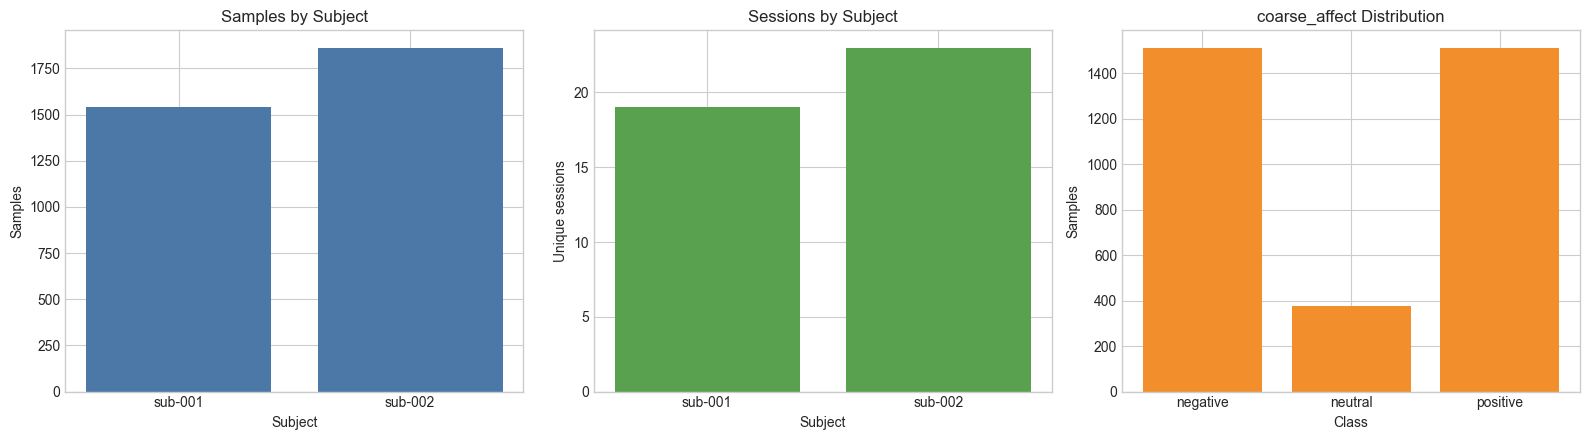

**Exact target mapping used in thesis pipeline**

,coarse_affect,emotion labels
0,positive,"happiness, pride, relief, interest"
1,neutral,neutral
2,negative,"anger, anxiety, disgust, sadness"


**Observed emotion -> coarse_affect pairs in index**

,emotion,coarse_affect
0,anger,negative
1,anxiety,negative
2,disgust,negative
3,sadness,negative
4,neutral,neutral
5,happiness,positive
6,interest,positive
7,pride,positive
8,relief,positive


In [3]:
index_df = read_csv(DATA_INDEX)
if index_df.empty:
    raise FileNotFoundError(f"Missing dataset index: {DATA_INDEX}")

overview = pd.DataFrame(
    {
        "stat": ["samples", "subjects", "sessions", "subject_session_bas groups", "tasks", "modalities"],
        "value": [
            len(index_df),
            index_df["subject"].nunique(),
            index_df["session"].nunique(),
            index_df["subject_session_bas"].nunique(),
            ", ".join(sorted(index_df["task"].dropna().unique())),
            ", ".join(sorted(index_df["modality"].dropna().unique())),
        ],
    }
)
display(Markdown("**Dataset overview**"))
display(overview)

subject_counts = index_df.groupby("subject", as_index=False).agg(samples=("sample_id", "count"), sessions=("session", "nunique"))
display(Markdown("**Subject counts**"))
display(subject_counts)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].bar(subject_counts["subject"], subject_counts["samples"], color="#4c78a8")
axes[0].set_title("Samples by Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Samples")

axes[1].bar(subject_counts["subject"], subject_counts["sessions"], color="#59a14f")
axes[1].set_title("Sessions by Subject")
axes[1].set_xlabel("Subject")
axes[1].set_ylabel("Unique sessions")

coarse_counts = index_df["coarse_affect"].value_counts().reindex(["negative", "neutral", "positive"]).fillna(0)
axes[2].bar(coarse_counts.index, coarse_counts.values, color="#f28e2b")
axes[2].set_title("coarse_affect Distribution")
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Samples")
fig.tight_layout()
plt.show()

mapping = pd.DataFrame(
    {
        "coarse_affect": ["positive", "neutral", "negative"],
        "emotion labels": [
            "happiness, pride, relief, interest",
            "neutral",
            "anger, anxiety, disgust, sadness",
        ],
    }
)
display(Markdown("**Exact target mapping used in thesis pipeline**"))
display(mapping)
display(Markdown("**Observed emotion -> coarse_affect pairs in index**"))
display(index_df[["emotion", "coarse_affect"]].drop_duplicates().sort_values(["coarse_affect", "emotion"]).reset_index(drop=True))


## 3) Methodological Safeguards (Leakage, Splits, Spatial)

- Explicit experiment mode recorded in each run config.
- Within-subject mode: one subject at a time, held-out sessions from the same subject.
- Frozen transfer mode: train on one subject, test on the other, no pooled CV semantics.
- Fold split manifest is exported for reconstruction.
- `spatial_compatibility_report.json` provides pre-fit spatial checks.
- Interpretability is exported only where supported and framed cautiously.


In [4]:
summary_rows = []
audit_rows = []

for k, meta in RUNS.items():
    r = RUN_DATA[k]
    cfg = r["config"] or {}
    m = r["metrics"] or {}
    sp = r["spatial"] or {}
    it = r["interp_summary"] or {}
    fs = r["fold_splits"]
    pr = r["predictions"]

    summary_rows.append(
        {
            "run": k,
            "run_id": meta["run_id"],
            "mode": cfg.get("experiment_mode", meta["mode"]),
            "subject": cfg.get("subject"),
            "train_subject": cfg.get("train_subject"),
            "test_subject": cfg.get("test_subject"),
            "target": cfg.get("target"),
            "model": cfg.get("model"),
            "seed": cfg.get("seed"),
            "accuracy": m.get("accuracy"),
            "balanced_accuracy": m.get("balanced_accuracy"),
            "macro_f1": m.get("macro_f1"),
            "spatial_passed": sp.get("passed"),
            "interpretability_status": it.get("status"),
        }
    )

    if fs.empty:
        audit_rows.append({"run": k, "subjects_ok": False, "split_logic_ok": False, "pred_subject_ok": False})
        continue

    split_logic_ok = False

    if meta["mode"] == "within_subject_loso_session":
        subj = meta["subject"]
        subjects_ok = (
            fs["train_subjects"].apply(lambda v: set(split_pipe(v)) == {subj}).all()
            and fs["test_subjects"].apply(lambda v: set(split_pipe(v)) == {subj}).all()
        )
        split_logic_ok = fs.apply(
            lambda row: set(split_pipe(row.get("train_sessions"))).isdisjoint(set(split_pipe(row.get("test_sessions")))),
            axis=1,
        ).all()
        pred_subject_ok = (not pr.empty) and pr["subject"].eq(subj).all()
    else:
        tr, te = meta["train_subject"], meta["test_subject"]
        subjects_ok = (
            tr != te
            and fs["train_subjects"].apply(lambda v: set(split_pipe(v)) == {tr}).all()
            and fs["test_subjects"].apply(lambda v: set(split_pipe(v)) == {te}).all()
        )
        split_logic_ok = bool(tr != te)
        pred_subject_ok = (not pr.empty) and pr["subject"].eq(te).all()

    audit_rows.append(
        {
            "run": k,
            "subjects_ok": bool(subjects_ok),
            "split_logic_ok": bool(split_logic_ok),
            "pred_subject_ok": bool(pred_subject_ok),
        }
    )

pilot_df = pd.DataFrame(summary_rows)
audit_df = pd.DataFrame(audit_rows)
display(Markdown("**Pilot run summary table**"))
display(pilot_df)
display(Markdown("**Split/membership audit checks from artifacts**"))
display(audit_df)


**Pilot run summary table**

,run,run_id,mode,subject,train_subject,test_subject,target,model,seed,accuracy,balanced_accuracy,macro_f1,spatial_passed,interpretability_status
0,within_sub001,healthcheck_20260311_within_sub001_ridge,within_subject_loso_session,sub-001,NaN,NaN,coarse_affect,ridge,42,0.712801,0.670565,0.666982,True,performed
1,within_sub002,healthcheck_20260311_within_sub002_ridge,within_subject_loso_session,sub-002,NaN,NaN,coarse_affect,ridge,42,0.635534,0.573269,0.574728,True,performed
2,transfer_001_to_002,healthcheck_20260311_transfer_sub001_to_sub002_ridge,frozen_cross_person_transfer,NaN,sub-001,sub-002,coarse_affect,ridge,42,0.478261,0.400966,0.385102,True,not_applicable
3,transfer_002_to_001,healthcheck_20260311_transfer_sub002_to_sub001_ridge,frozen_cross_person_transfer,NaN,sub-002,sub-001,coarse_affect,ridge,42,0.463938,0.422515,0.398450,True,not_applicable


**Split/membership audit checks from artifacts**

,run,subjects_ok,split_logic_ok,pred_subject_ok
0,within_sub001,True,True,True
1,within_sub002,True,True,True
2,transfer_001_to_002,True,True,True
3,transfer_002_to_001,True,True,True


## 4) Within-Subject and Transfer Results


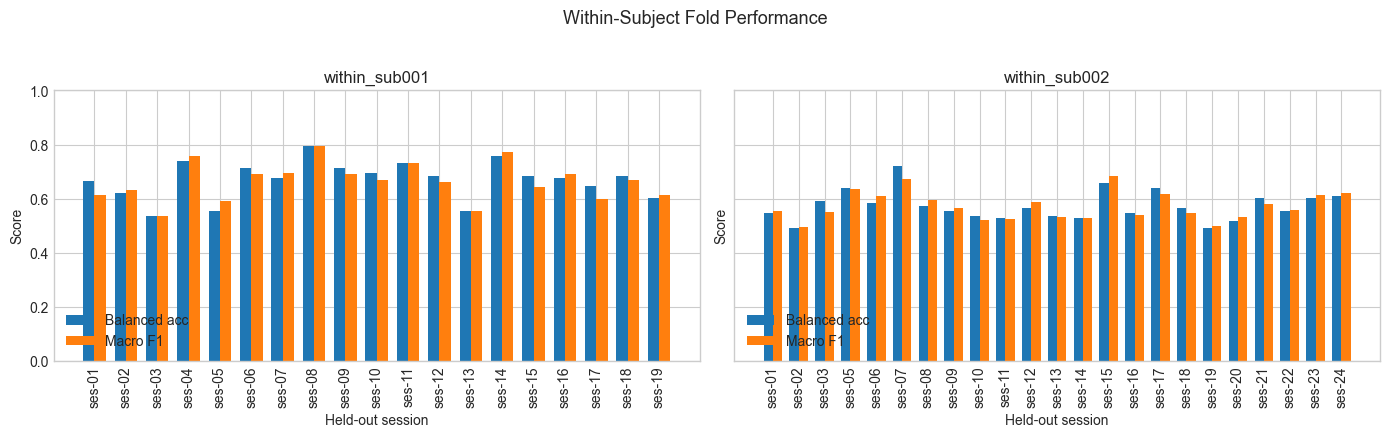

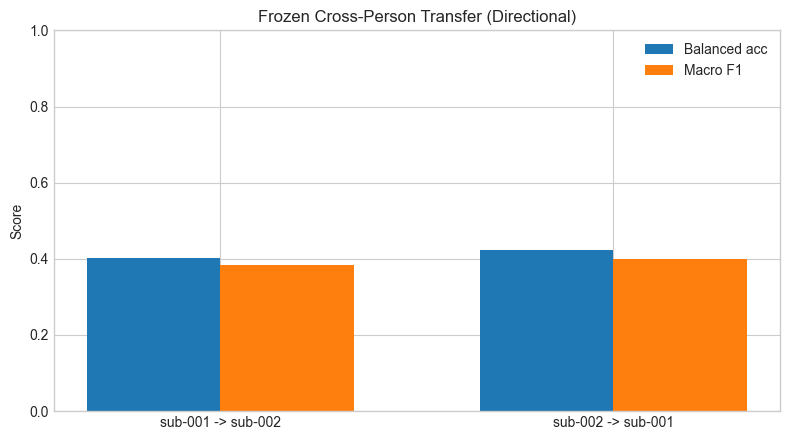

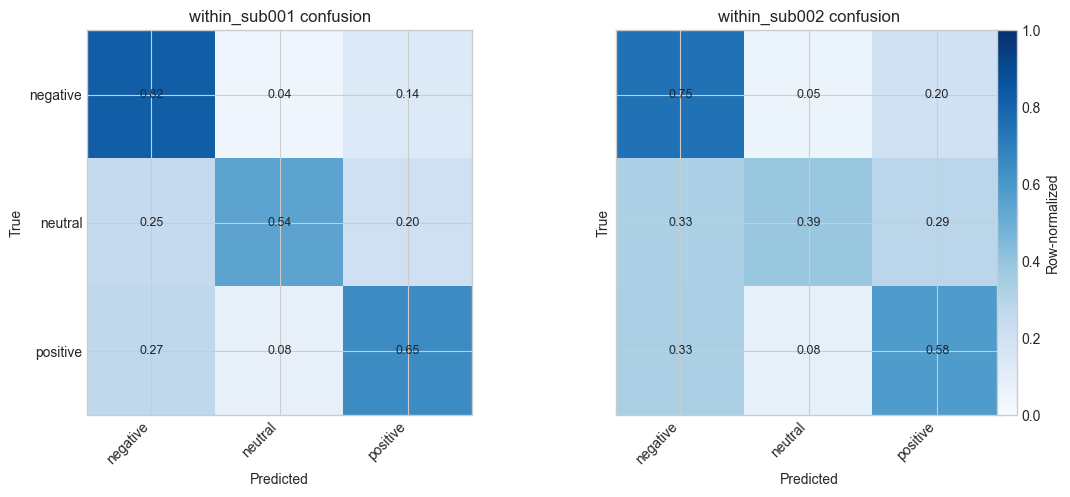

In [5]:
within = [k for k, v in RUNS.items() if v["mode"] == "within_subject_loso_session"]
transfer = [k for k, v in RUNS.items() if v["mode"] == "frozen_cross_person_transfer"]

if within:
    fig, axes = plt.subplots(1, len(within), figsize=(7 * len(within), 4.2), sharey=True)
    if len(within) == 1:
        axes = [axes]
    for ax, k in zip(axes, within):
        fm = RUN_DATA[k]["fold_metrics"].sort_values("fold")
        if fm.empty:
            ax.text(0.5, 0.5, "missing fold_metrics", ha="center", va="center")
            continue
        x = np.arange(len(fm))
        ax.bar(x - 0.18, fm["balanced_accuracy"], 0.36, label="Balanced acc")
        ax.bar(x + 0.18, fm["macro_f1"], 0.36, label="Macro F1")
        labels = fm["test_sessions"] if "test_sessions" in fm.columns else fm["test_groups"]
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90)
        ax.set_ylim(0, 1)
        ax.set_title(k)
        ax.set_xlabel("Held-out session")
        ax.set_ylabel("Score")
        ax.legend(loc="lower left")
    fig.suptitle("Within-Subject Fold Performance", y=1.03, fontsize=13)
    fig.tight_layout()
    plt.show()

if transfer:
    tdf = pilot_df[pilot_df["mode"] == "frozen_cross_person_transfer"].copy()
    if not tdf.empty:
        tdf["direction"] = tdf["train_subject"] + " -> " + tdf["test_subject"]
        x = np.arange(len(tdf))
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.bar(x - 0.17, tdf["balanced_accuracy"], 0.34, label="Balanced acc")
        ax.bar(x + 0.17, tdf["macro_f1"], 0.34, label="Macro F1")
        ax.set_xticks(x)
        ax.set_xticklabels(tdf["direction"])
        ax.set_ylim(0, 1)
        ax.set_title("Frozen Cross-Person Transfer (Directional)")
        ax.set_ylabel("Score")
        ax.legend()
        fig.tight_layout()
        plt.show()

labels = ["negative", "neutral", "positive"]
if within:
    fig, axes = plt.subplots(1, len(within), figsize=(6.2 * len(within), 5), sharey=True)
    if len(within) == 1:
        axes = [axes]
    for ax, k in zip(axes, within):
        pred = RUN_DATA[k]["predictions"]
        if pred.empty:
            ax.text(0.5, 0.5, "missing predictions", ha="center", va="center")
            continue
        cm = pd.crosstab(pred["y_true"], pred["y_pred"], normalize="index").reindex(index=labels, columns=labels, fill_value=0)
        im = ax.imshow(cm.values, vmin=0, vmax=1, cmap="Blues")
        ax.set_title(f"{k} confusion")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, f"{cm.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=axes, fraction=0.03, pad=0.04, label="Row-normalized")
    fig.subplots_adjust(right=0.88, wspace=0.3)
    plt.show()


### Held-Out Session Membership by Fold (Within-Subject)


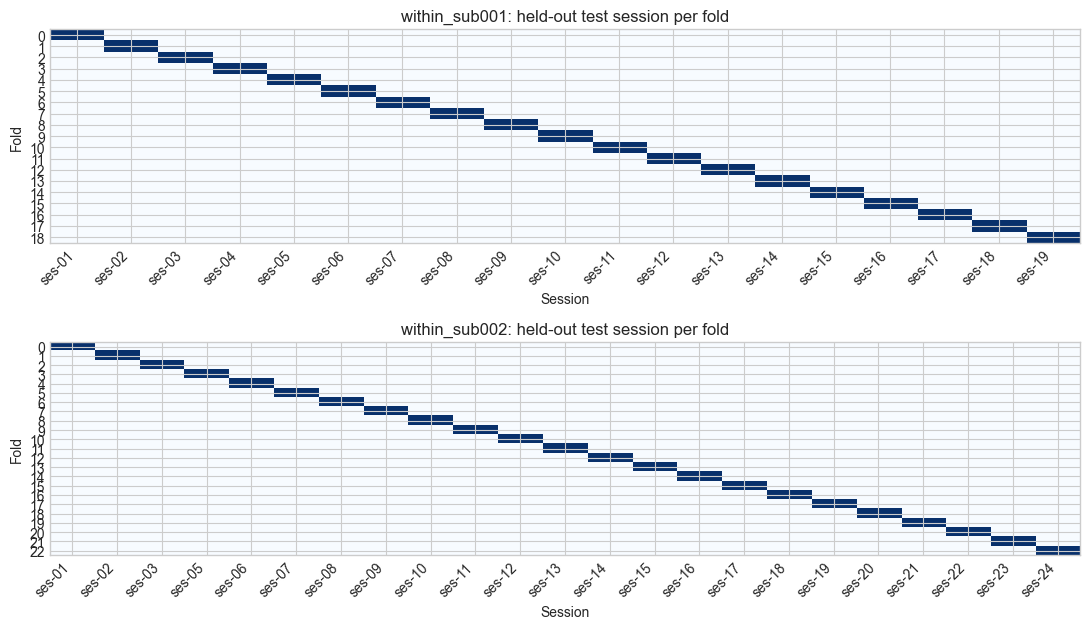

In [6]:
if within:
    fig, axes = plt.subplots(len(within), 1, figsize=(11, 3.2 * len(within)))
    if len(within) == 1:
        axes = [axes]
    for ax, k in zip(axes, within):
        fs = RUN_DATA[k]["fold_splits"].sort_values("fold")
        if fs.empty:
            ax.text(0.5, 0.5, "missing fold_splits", ha="center", va="center")
            ax.axis("off")
            continue
        sessions = sorted({s for v in fs["test_sessions"] for s in split_pipe(v)})
        mat = np.zeros((len(fs), len(sessions)), dtype=int)
        for i, (_, row) in enumerate(fs.iterrows()):
            for ses in split_pipe(row["test_sessions"]):
                mat[i, sessions.index(ses)] = 1
        ax.imshow(mat, aspect="auto", cmap="Blues", vmin=0, vmax=1)
        ax.set_yticks(np.arange(len(fs)))
        ax.set_yticklabels(fs["fold"].tolist())
        ax.set_xticks(np.arange(len(sessions)))
        ax.set_xticklabels(sessions, rotation=45, ha="right")
        ax.set_title(f"{k}: held-out test session per fold")
        ax.set_xlabel("Session")
        ax.set_ylabel("Fold")
    fig.tight_layout()
    plt.show()


## 5) Interpretability and Spatial-Compatibility Artifacts

Interpretability is shown only for supported linear within-subject runs and should be interpreted as **model-behavior robustness evidence**.


**Interpretability summary**

,run,status,n_fold_artifacts,mean_pairwise_correlation,mean_sign_consistency,mean_top_k_overlap,caution
0,within_sub001,performed,19,0.929657,0.919372,0.486634,Linear coefficients are reported as model-behavior evidence only and must not be interpreted as direct neural locali...
1,within_sub002,performed,23,0.935432,0.922298,0.370297,Linear coefficients are reported as model-behavior evidence only and must not be interpreted as direct neural locali...
2,transfer_001_to_002,not_applicable,0,NaN,NaN,NaN,Linear coefficients are reported as model-behavior evidence only and must not be interpreted as direct neural locali...
3,transfer_002_to_001,not_applicable,0,NaN,NaN,NaN,Linear coefficients are reported as model-behavior evidence only and must not be interpreted as direct neural locali...


**Spatial compatibility summary**

,run,status,passed,n_groups_checked,affine_atol,feature_count,mask_sha256_prefix
0,within_sub001,passed,True,19,0.00001,199209,b3766b4d56de
1,within_sub002,passed,True,23,0.00001,199209,b3766b4d56de
2,transfer_001_to_002,passed,True,42,0.00001,199209,b3766b4d56de
3,transfer_002_to_001,passed,True,42,0.00001,199209,b3766b4d56de


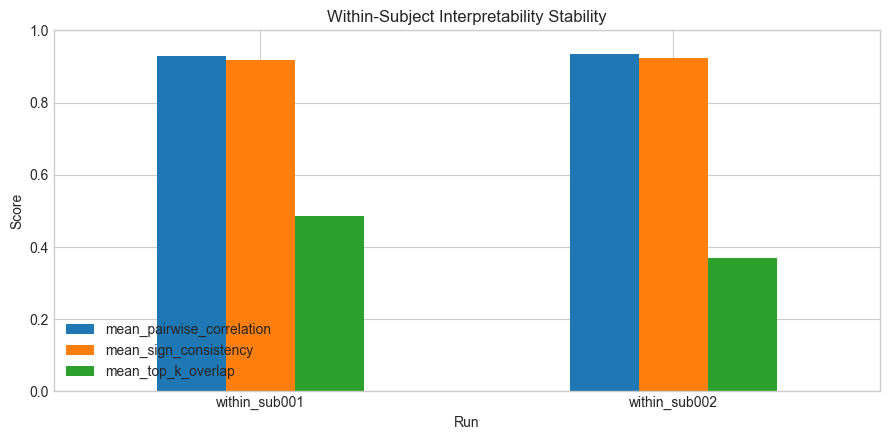

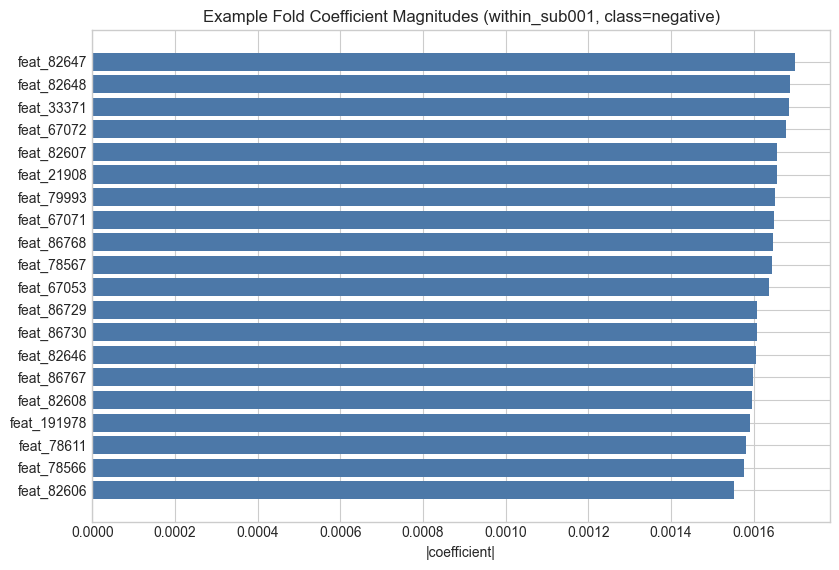

Coefficient preview is presented in feature-index space only; no anatomical claims are made.

In [7]:
interp_rows = []
spatial_rows = []
for k in RUNS:
    it = RUN_DATA[k]["interp_summary"] or {}
    st = it.get("stability") or {}
    interp_rows.append(
        {
            "run": k,
            "status": it.get("status"),
            "n_fold_artifacts": it.get("n_fold_artifacts"),
            "mean_pairwise_correlation": st.get("mean_pairwise_correlation"),
            "mean_sign_consistency": st.get("mean_sign_consistency"),
            "mean_top_k_overlap": st.get("mean_top_k_overlap"),
            "caution": it.get("caution"),
        }
    )
    sp = RUN_DATA[k]["spatial"] or {}
    ref = sp.get("reference_signature") or {}
    spatial_rows.append(
        {
            "run": k,
            "status": sp.get("status"),
            "passed": sp.get("passed"),
            "n_groups_checked": sp.get("n_groups_checked"),
            "affine_atol": sp.get("affine_atol"),
            "feature_count": ref.get("feature_count"),
            "mask_sha256_prefix": (ref.get("mask_sha256") or "")[:12],
        }
    )

interp_df = pd.DataFrame(interp_rows)
spatial_df = pd.DataFrame(spatial_rows)
display(Markdown("**Interpretability summary**"))
display(interp_df)
display(Markdown("**Spatial compatibility summary**"))
display(spatial_df)

plot_df = interp_df[interp_df["status"] == "performed"].set_index("run")
if not plot_df.empty:
    cols = ["mean_pairwise_correlation", "mean_sign_consistency", "mean_top_k_overlap"]
    ax = plot_df[cols].plot(kind="bar", figsize=(9, 4.5), ylim=(0, 1))
    ax.set_title("Within-Subject Interpretability Stability")
    ax.set_ylabel("Score")
    ax.set_xlabel("Run")
    plt.xticks(rotation=0)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

example = "within_sub001" if "within_sub001" in RUN_DATA else None
if example is not None:
    fold_table = RUN_DATA[example]["interp_folds"]
    if not fold_table.empty:
        coef_path = Path(fold_table.iloc[0]["coefficient_file"])
        if coef_path.exists():
            blob = np.load(coef_path, allow_pickle=True)
            coefs = blob["coefficients"]
            class_labels = blob["class_labels"]
            feat_idx = blob["feature_index"]
            cls = 0
            mag = np.abs(coefs[cls])
            top_n = 20
            top = np.argsort(mag)[-top_n:][::-1]
            fig, ax = plt.subplots(figsize=(8.5, 5.8))
            ax.barh(np.arange(top_n), mag[top][::-1], color="#4c78a8")
            ax.set_yticks(np.arange(top_n))
            ax.set_yticklabels([f"feat_{int(feat_idx[i])}" for i in top][::-1])
            ax.set_title(f"Example Fold Coefficient Magnitudes ({example}, class={class_labels[cls]})")
            ax.set_xlabel("|coefficient|")
            plt.tight_layout()
            plt.show()
            display(Markdown("Coefficient preview is presented in feature-index space only; no anatomical claims are made."))


## 6) Artifact Completeness and Readiness View


In [8]:
presence = []
for k, meta in RUNS.items():
    d = run_dir(k)
    row = {"run": k, "run_id": meta["run_id"]}
    for a in ARTIFACTS:
        row[a] = (d / a).exists()
    row["interpretability_dir"] = (d / "interpretability").exists()
    row["n_coef_npz"] = len(list((d / "interpretability").glob("*.npz"))) if (d / "interpretability").exists() else 0
    presence.append(row)
presence_df = pd.DataFrame(presence)
display(Markdown("**Artifact presence matrix**"))
display(presence_df)

artifact_guide = pd.DataFrame(
    [
        ["config.json", "Run definition: mode, subject(s), target/model, seed, software versions."],
        ["metrics.json", "Aggregate run metrics + confusion matrix."],
        ["fold_metrics.csv", "Fold-level performance metrics."],
        ["fold_splits.csv", "Auditable train/test split membership and counts."],
        ["predictions.csv", "Row-level predictions with metadata and labels."],
        ["spatial_compatibility_report.json", "Pre-fit spatial signature validation outcome."],
        ["interpretability_summary.json", "Interpretability status + stability statistics."],
        ["interpretability_fold_explanations.csv", "Fold-level explanation metadata + coefficient file paths."],
        ["interpretability/*.npz", "Fold coefficient arrays for supported linear within-subject runs."],
    ],
    columns=["artifact", "purpose"],
)
display(Markdown("**Artifact reference**"))
display(artifact_guide)


**Artifact presence matrix**

,run,run_id,config.json,metrics.json,fold_metrics.csv,fold_splits.csv,predictions.csv,spatial_compatibility_report.json,interpretability_summary.json,interpretability_fold_explanations.csv,interpretability_dir,n_coef_npz
0,within_sub001,healthcheck_20260311_within_sub001_ridge,True,True,True,True,True,True,True,True,True,19
1,within_sub002,healthcheck_20260311_within_sub002_ridge,True,True,True,True,True,True,True,True,True,23
2,transfer_001_to_002,healthcheck_20260311_transfer_sub001_to_sub002_ridge,True,True,True,True,True,True,True,False,False,0
3,transfer_002_to_001,healthcheck_20260311_transfer_sub002_to_sub001_ridge,True,True,True,True,True,True,True,False,False,0


**Artifact reference**

,artifact,purpose
0,config.json,"Run definition: mode, subject(s), target/model, seed, software versions."
1,metrics.json,Aggregate run metrics + confusion matrix.
2,fold_metrics.csv,Fold-level performance metrics.
3,fold_splits.csv,Auditable train/test split membership and counts.
4,predictions.csv,Row-level predictions with metadata and labels.
5,spatial_compatibility_report.json,Pre-fit spatial signature validation outcome.
6,interpretability_summary.json,Interpretability status + stability statistics.
7,interpretability_fold_explanations.csv,Fold-level explanation metadata + coefficient file paths.
8,interpretability/*.npz,Fold coefficient arrays for supported linear within-subject runs.


## 7) Final Thesis-Aligned Takeaways

- The pipeline is implemented, auditable, and evidenced by real pilot artifact sets.
- Primary and secondary experiment families are clearly separated and operational.
- Spatial compatibility safeguards and fold manifests support methodological trust.
- Interpretability outputs provide cautious model-behavior robustness evidence only.

This notebook is intended as a presentation-ready operational summary for supervisor review before broader experiment batches.
